# Soil Organic Carbon Data 

In [120]:
# 🔄 Optional: Automatically reload imports if the source code changes
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
import ee

ee.Authenticate()
ee.Initialize()

In [122]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geemap as gm

sns.set_theme(style="whitegrid")
sns.set_context("talk")

# Import Local Data
Get all data that is alredy downloaded.

## Point Shapefile

In [123]:
path_to_soc_shp = './data/other_vectors/sichei_attr.shp'
path_to_soc_csv = './data/other_vectors/sichei_attr.csv'

# Load the shapefile
soc_gdf = gpd.read_file(path_to_soc_shp)

print(f'Columns GDF \n {soc_gdf.columns}')
print(f'Number of rows: {soc_gdf.shape[0]}')

soc = pd.read_csv(path_to_soc_csv)
print(f'Columns DF \n {soc.columns}')
print(f'Number of rows: {soc.shape[0]}')

soc.head()

Columns GDF 
 Index(['Site', 'Cluster', 'Plot', 'Depthcode', 'predSOC', 'Date', 'Latitude',
       'Longitude', 'Altitude', 'geometry'],
      dtype='object')
Number of rows: 319
Columns DF 
 Index(['Site', 'Cluster', 'Plot', 'Depthcode', 'predSOC', 'Date', 'Latitude',
       'Longitude', 'Altitude'],
      dtype='object')
Number of rows: 319


,Site,Cluster,Plot,Depthcode,predSOC,Date,Latitude,Longitude,Altitude
0,Sichei,1.0,1.0,Topsoil,11.246,10-Mar-21,0.711449,34.6406,1544.81
1,Sichei,1.0,1.0,Subsoil,8.619,10-Mar-21,0.711449,34.6406,1544.81
2,Sichei,2.0,1.0,Topsoil,11.516,11-Mar-21,0.731318,34.6339,1552.42
3,Sichei,2.0,1.0,Subsoil,9.866,11-Mar-21,0.731318,34.6339,1552.42
4,Sichei,3.0,1.0,Topsoil,14.464,12-Mar-21,0.768700,34.6443,1611.33


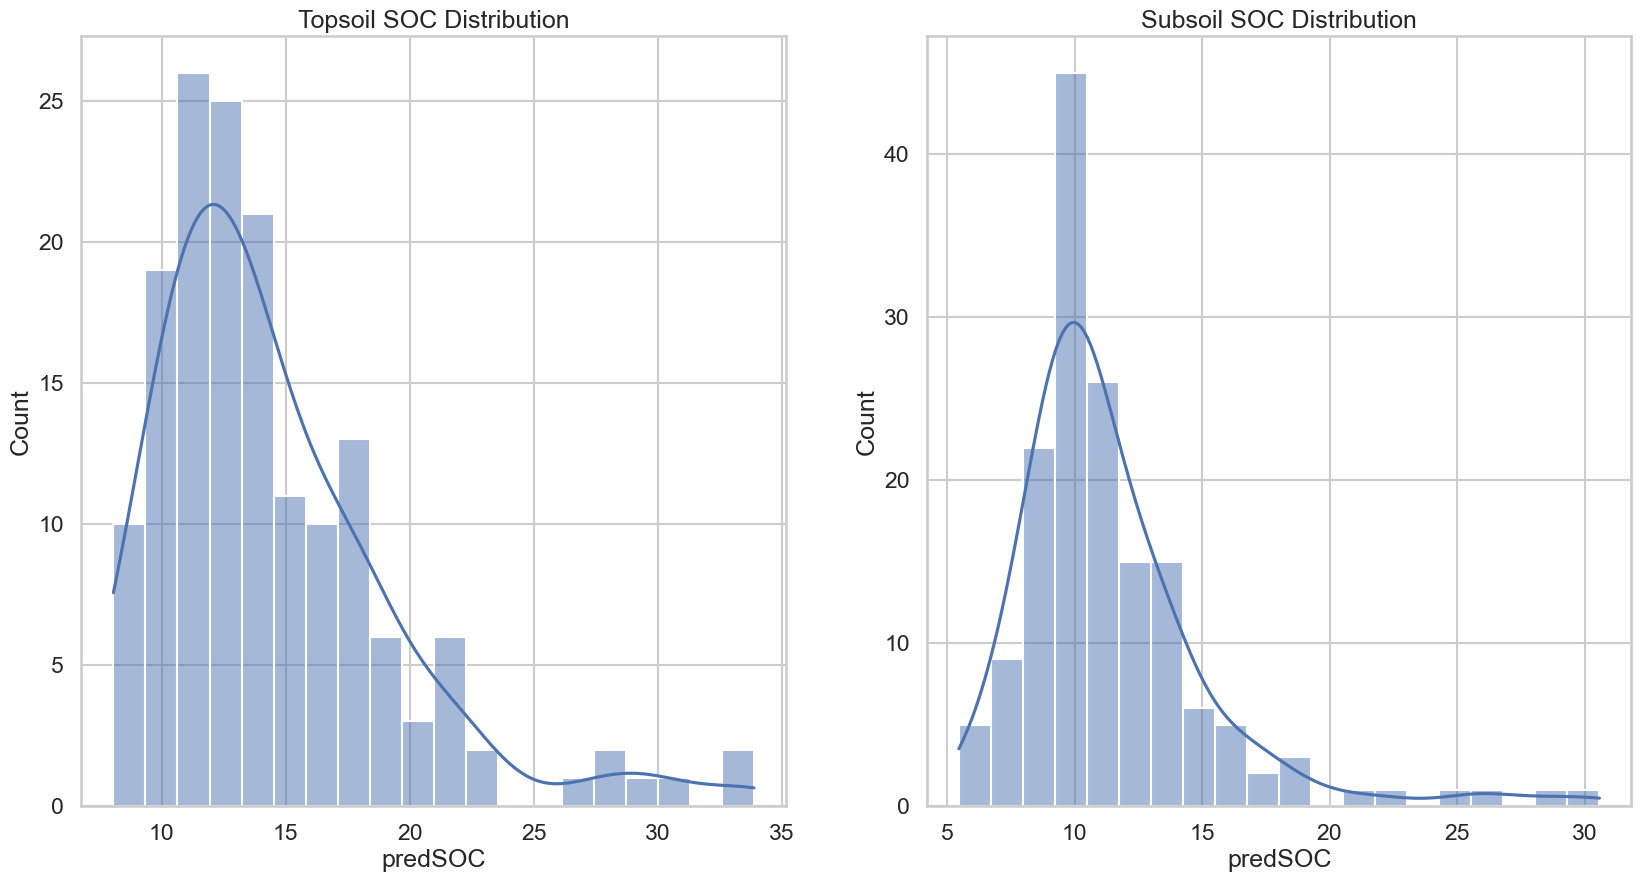

In [124]:
# Split into top and subsoil
topsoil = soc[soc['Depthcode'] == 'Topsoil']
subsoil = soc[soc['Depthcode'] == 'Subsoil']

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(topsoil['predSOC'], bins=20, kde=True, ax=ax[0])
ax[0].set_title('Topsoil SOC Distribution')

sns.histplot(subsoil['predSOC'], bins=20, kde=True, ax=ax[1])
ax[1].set_title('Subsoil SOC Distribution')

plt.show()

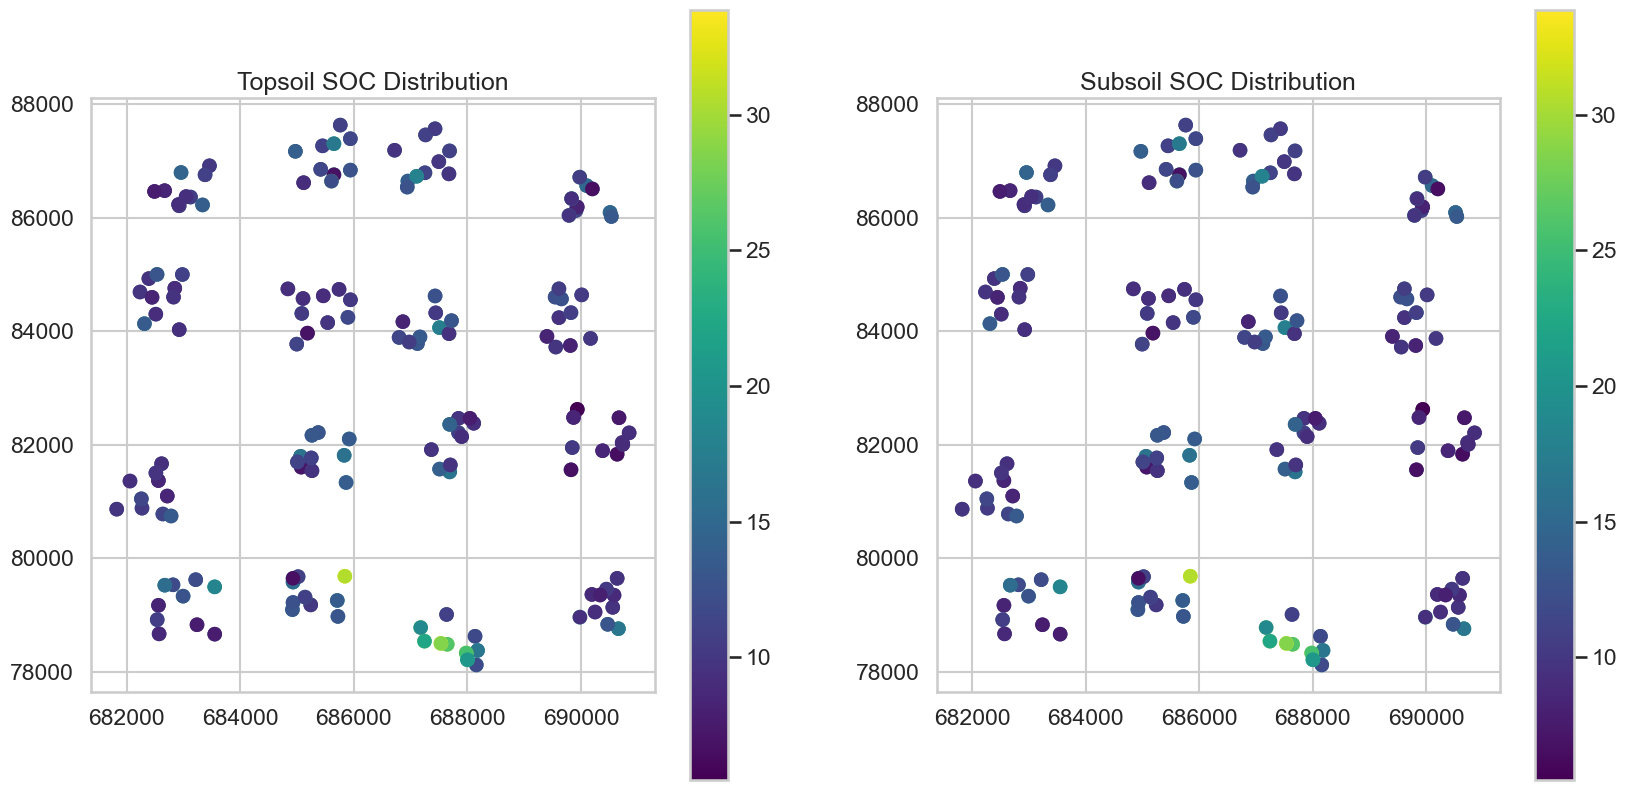

In [125]:
# Spatial Plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

soc_gdf.plot(column='predSOC', cmap='viridis', legend=True, ax=ax[0])
ax[0].set_title('Topsoil SOC Distribution')

soc_gdf.plot(column='predSOC', cmap='viridis', legend=True, ax=ax[1])
ax[1].set_title('Subsoil SOC Distribution')

plt.show()



In [126]:
# Merge the topsoil and subsoil data
soc_gdf = soc_gdf.pivot_table(index='geometry', values='predSOC', aggfunc='mean').reset_index()
soc_gdf = gpd.GeoDataFrame(soc_gdf, geometry='geometry')
soc_gdf.head()

,geometry,predSOC
0,POINT (682568.835 78668.993),9.9325
1,POINT (682535.352 78918.883),12.5035
2,POINT (682557.524 79171.778),9.4790
3,POINT (682668.709 79526.324),16.8675
4,POINT (682813.413 79533.121),15.0005


In [127]:
import random
import string
import pandas as pd

def generate_id(length=4):
    """Generate a random ID with a maximum length of 4 characters.
    
    Args:
        length (int): Length of the ID (default: 4)
    
    Returns:
        str: Random ID consisting of uppercase letters and digits
    """
    # Ensure length is not more than 4
    if length > 4:
        length = 4
    
    # Define characters to use (uppercase letters and digits)
    characters = string.ascii_uppercase + string.digits
    
    # Generate and return the random ID
    return ''.join(random.choice(characters) for _ in range(length))

def add_ids_to_dataset(df, id_column_name='ID'):
    """Add unique 4-character IDs as a new column to a dataframe.
    
    Args:
        df (pandas.DataFrame): The dataframe to add IDs to
        id_column_name (str): Name for the ID column (default: 'ID')
    
    Returns:
        pandas.DataFrame: Dataframe with the new ID column
    """
    # Generate a list of unique IDs equal to the length of the dataframe
    num_rows = len(df)
    unique_ids = set()
    
    while len(unique_ids) < num_rows:
        unique_ids.add(generate_id())
    
    # Convert set to list and add as a new column to the dataframe
    df[id_column_name] = list(unique_ids)
    
    return df
soc_gdf = add_ids_to_dataset(soc_gdf, id_column_name='PointID')
soc_gdf.set_index('PointID', inplace=True)

In [128]:
soc_gdf

,geometry,predSOC
PointID,,
1GYL,POINT (682568.835 78668.993),9.9325
X3L4,POINT (682535.352 78918.883),12.5035
LQ8E,POINT (682557.524 79171.778),9.4790
ZTB7,POINT (682668.709 79526.324),16.8675
9HYQ,POINT (682813.413 79533.121),15.0005
...,...,...
L8QB,POINT (690661.361 78760.068),19.2500
0WR2,POINT (690472.095 78837.403),14.3065
ZPKW,POINT (690561.036 79136.223),9.9895


## The Bounding of the Data

Since I shall be getting data from Google Earth Engine using the python API, it is important to describe the bounding box of the dataset. 
This will be achieved by describing the extent of the data then, provinding a buffer of 2km around the extent. The resulting polygon will then be exported as the `bbox` of the region of study

In [129]:
from shapely.geometry import box
xmin, ymin, xmax, ymax = soc_gdf.total_bounds
bbox = box(xmin, ymin, xmax, ymax)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs=soc_gdf.crs)
buffered_bbox_gdf = bbox_gdf.buffer(500)
buffered_bbox_gdf = gpd.GeoDataFrame(geometry=buffered_bbox_gdf, crs=soc_gdf.crs)

def get_geodataframe_extent(gdf):
    """
    Creates a GeoDataFrame representing the total extent (bounding box) of an input GeoDataFrame.
    
    Parameters:
    -----------
    gdf : geopandas.GeoDataFrame
        Input GeoDataFrame containing geometries
    
    Returns:
    --------
    geopandas.GeoDataFrame
        A new GeoDataFrame containing a single polygon representing the bounding box
    """
    import geopandas as gpd
    from shapely.geometry import box
    
    # Get the total bounds of the GeoDataFrame
    # This returns [minx, miny, maxx, maxy]
    bounds = gdf.total_bounds
    
    # Create a shapely box (rectangle) from the bounds
    bbox = box(*bounds)
    
    # Create a new GeoDataFrame with the bounding box
    bbox_gdf = gpd.GeoDataFrame(
        {'geometry': [bbox]},
        crs=gdf.crs
    )
    
    return bbox_gdf

square_bbox_gdf = get_geodataframe_extent(buffered_bbox_gdf)
# COnvert the bounding box to ee.Geometry
bbox_ee = gm.geopandas_to_ee(square_bbox_gdf)

square_bbox_gdf.to_file("./data/other_vectors/bbox.shp", driver='ESRI Shapefile')

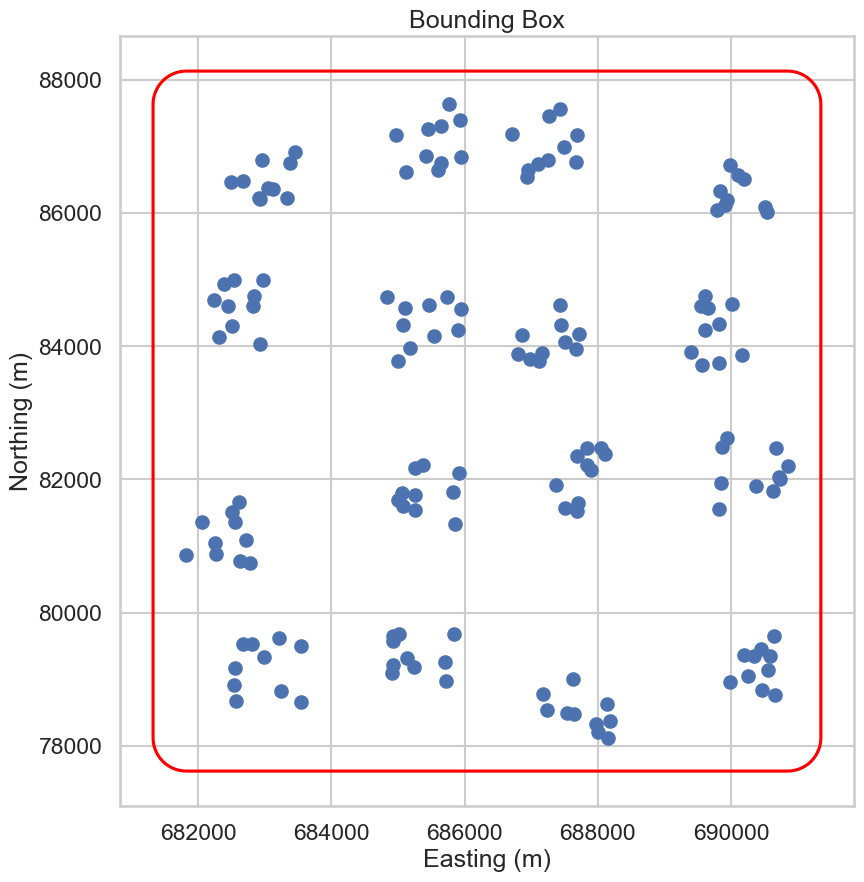

In [130]:
# Plot the bbox
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
soc_gdf.plot(ax=ax)
buffered_bbox_gdf.boundary.plot(ax=ax, color='red')
plt.title('Bounding Box')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)') 
plt.show()

# Google Earth Data Processing

Data from Google Earth Engine for Predicting Soil Organic Carbon.  
The following datasets will be used in the study:
- Sentinel-1 (and Derivatives)
- Sentinel-2 (and Deivatives)
- Land Use Land Cover
- WAPOR Evapotranspiration

### Sentinel 1 RADAR Data 
Collection of SAR data from the COPERNICUS collection

In [131]:
def mask_edge(image):
    edge = image.lt(-30.0)
    masked_image = image.mask().And(edge.Not())
    return image.updateMask(masked_image)

In [132]:
img_vv_vh = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select(['VV','VH'])  
    .map(mask_edge)
)

focus_date = ee.Filter.date('2021-03-01', '2021-03-20')
img_mean = img_vv_vh.filter(focus_date).mean().clip(bbox_ee)

### Sentinel 1 SAR Derivatives 

The indices of sentinel-1 can be used to give insight into subsurface properties. 
The following indices will be computed:
#### VH/VV Ratio (VVVHR)

> This index helps to understand soil moisture and surface roughness, which are correlated with SOC.
$$
VVVH R = \frac{VV}{VH}
$$

#### Radar Vegetation Index

$$
RVI = \frac{4 *VH}{VV+VH}
$$

#### Normalized Difference Index

$$
NDI = \frac{VV-VH}{VV+VH}
$$

#### Cross-Polarization Ratio  

​$$
CPR = \frac{VV-VH}{VV+VH}
$$



In [133]:
# import Sentinel1SARIndices class
from soc_scripts.gee_functions import Sentinel1SARIndices

# Instantiate the class with the Sentinel-1 image
sar_indices = Sentinel1SARIndices(img_mean)

# Apply all indices
processed_image = sar_indices.apply_all_indices()

In [134]:
from soc_scripts.extraction import stack_rasters
# Convert FeatureCollection to Geometry if needed
bbox_ee = bbox_ee.geometry() if isinstance(bbox_ee, ee.FeatureCollection) else bbox_ee

# Export the Image to local directory
filename = './data/exports/s1/sentinel1.tif'

gm.ee_export_image(
    processed_image, 
    filename=filename, 
    scale=20, 
    region=bbox_ee, 
    file_per_band=True,
    crs='EPSG:32636'
    )
# stack_rasters('./data/exports/s1', 'sentinel1_stack.tif')

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\s1


In [135]:
sarMap = gm.Map()
sarMap.center_object(bbox_ee, 12)
sarMap.add_layer(img_mean, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
sarMap

Map(center=[0.7494919285650635, 34.67445462520001], controls=(WidgetControl(options=['position', 'transparent_…

In [136]:
# Sample the data from the image using the points from the shapefile
soc_points = gm.geopandas_to_ee(soc_gdf)

socsoil_points = img_mean.sampleRegions(
    collection=soc_points,
    scale=10,
    geometries=True
)

### Sentinel 2 MSI Data


In [137]:
def mask_s2_clouds(image):
    """Masks clouds in a Sentinel-2 image using the QA band.

    Args:
        image (ee.Image): A Sentinel-2 image.

    Returns:
        ee.Image: A cloud-masked Sentinel-2 image.
    """
    qa = image.select('QA60')

    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    # Both flags should be set to zero, indicating clear conditions.
    mask = (
        qa.bitwiseAnd(cloud_bit_mask)
        .eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    return image.updateMask(mask).divide(10000)


dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2021-03-01', '2021-04-01')
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .select(['B2', 'B3', 'B4','B5','B6','B7','B8', 'B8A','B9', 'B11', 'B12']) 
    .mean().clip(bbox_ee)
)


### Sentinel-2 Indices for Soil Organic Carbon Estimation

Sentinel-2 provides multispectral imagery that is useful for estimating Soil Organic Carbon (SOC). Several vegetation and soil indices derived from Sentinel-2 bands can be correlated with SOC.

#### 1. Normalized Difference Vegetation Index (NDVI)
NDVI is commonly used to assess vegetation health and biomass, both of which are linked to SOC.

$$
NDVI = \frac{B8 - B4}{B8 + B4}
$$

#### 2. Normalized Difference Soil Index (NDSI)
NDSI helps distinguish bare soil from vegetation and can be useful in SOC estimation.

$$
NDSI = \frac{B11 - B4}{B11 + B4}
$$

#### 3. Soil Adjusted Vegetation Index (SAVI)
SAVI accounts for soil brightness and is useful in semi-arid and arid regions.

$$
SAVI = \frac{(B8 - B4) \times (1 + L)}{B8 + B4 + L}
$$

where \( L \) is a soil brightness correction factor (typically 0.5).

#### 4. Bare Soil Index (BSI)
BSI helps in detecting bare soil areas, which are important for SOC estimation.

$$
BSI = \frac{(B11 + B4) - (B8 + B2)}{(B11 + B4) + (B8 + B2)}
$$

#### 5. Normalized Burn Ratio (NBR)
NBR is useful for assessing soil conditions after disturbances such as wildfires, which influence SOC.

$$
NBR = \frac{B8 - B12}{B8 + B12}
$$

These indices provide valuable insights into vegetation, soil properties, and moisture levels, all of which are essential for estimating Soil Organic Carbon (SOC). They can be used in combination with machine learning models or regression analyses for SOC prediction.




In [138]:
from soc_scripts.gee_functions import Sentinel2Indices
# Instantiate the class with the Sentinel-2 image
s2_indices = Sentinel2Indices(dataset)
# Apply all indices
processed_s2_image = s2_indices.apply_all_indices()


In [139]:
from soc_scripts.extraction import stack_rasters
# Convert FeatureCollection to Geometry if needed
bbox_ee = bbox_ee.geometry() if isinstance(bbox_ee, ee.FeatureCollection) else bbox_ee

# Export the Image to local directory
filename = './data/exports/s2/sentinel2.tif'

gm.ee_export_image(
    processed_s2_image, 
    filename=filename, 
    scale=20, 
    region=bbox_ee, 
    file_per_band=True,
    crs='EPSG:32636'
    )
# stack_rasters('./data/exports/s2', 'sentinel2_stack.tif')

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\s2


In [140]:
visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

m = gm.Map()
m.center_object(bbox_ee, 12)
m.add_layer(dataset, visualization, 'RGB')
m

Map(center=[0.7494919285650635, 34.67445462520001], controls=(WidgetControl(options=['position', 'transparent_…

## MODIS Data

### MODIS Evapotranspiration Data

In [141]:
# Modis Evapotranspiration ee.ImageCollection("MODIS/061/MOD16A2")

modis_et = ee.ImageCollection("MODIS/061/MOD16A2") \
    .filterDate('2021-03-01', '2021-04-01') \
    .filterBounds(bbox_ee) \
    .select('ET') \
    .mean().clip(bbox_ee)

modis_et.getInfo()

{'type': 'Image',
 'bands': [{'id': 'ET',
   'data_type': {'type': 'PixelType',
    'precision': 'double',
    'min': -32768,
    'max': 32767},
   'dimensions': [2, 2],
   'origin': [34, 0],
   'crs': 'EPSG:4326',
   'crs_transform': [1, 0, 0, 0, 1, 0]}],
 'properties': {'system:footprint': {'type': 'Polygon',
   'coordinates': [[[34.71947611078594, 0.701950804175622],
     [34.71951318676219, 0.796997917116014],
     [34.62943286411286, 0.797034790826959],
     [34.62939772828696, 0.701983280009046],
     [34.71947611078594, 0.701950804175622]]]}}}

In [142]:
filename = './data/exports/modis_et.tif'
gm.ee_export_image(
    modis_et, 
    filename=filename, 
    scale=500, 
    region=bbox_ee, 
    file_per_band=False,
    crs='EPSG:32636'
    )

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\modis_et.tif


### MODIS Land Surface Temperature

In [143]:
# MODIS Land Surface Temperature ee.ImageCollection("MODIS/061/MOD11A2")
modis_lst = ee.ImageCollection("MODIS/061/MOD11A2") \
    .filterDate('2021-03-01', '2021-04-01') \
    .filterBounds(bbox_ee) \
    .select('LST_Day_1km') \
    .mean().clip(bbox_ee)

In [144]:
filename = './data/exports/modis_lst.tif'
gm.ee_export_image(
    modis_lst, 
    filename=filename, 
    scale=1000, 
    region=bbox_ee, 
    file_per_band=False,
    crs='EPSG:32636'
    )

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\modis_lst.tif


## Land Use & Land Cover

In [145]:
# Dynamic World Lulc ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
dynamic_world = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1") \
    .filterDate('2021-03-01', '2021-04-01') \
    .filterBounds(bbox_ee) \
    .select('label') \
    .mean().clip(bbox_ee)

filename = './data/exports/dynamic_world_lulc.tif'
gm.ee_export_image(
    dynamic_world, 
    filename=filename, 
    scale=10, 
    region=bbox_ee, 
    file_per_band=False,
    crs='EPSG:32636'
    )

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\dynamic_world_lulc.tif


## CHIRPS Precipitation Data

In [146]:
# CHIRPS precipitation data ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
    .filterDate('2021-03-01', '2021-04-01') \
    .filterBounds(bbox_ee) \
    .select('precipitation') \
    .sum().clip(bbox_ee)
filename = './data/exports/chirps_precipitation.tif'
gm.ee_export_image(
    chirps, 
    filename=filename, 
    scale=500, 
    region=bbox_ee, 
    file_per_band=False,
    crs='EPSG:32636'
    )

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\chirps_precipitation.tif


## Soil Ph

In [147]:
#  Download the ph Image from GEE ee.Image("ISDASOIL/Africa/v1/ph")
ph = ee.Image("ISDASOIL/Africa/v1/ph").clip(bbox_ee)
# Get band 1 mean_0_20
ph_0_20 = ph.select('mean_0_20').rename('ph_0_20')

In [148]:
# Export the Image to local directory
filename = './data/exports/ph_0_20.tif'
gm.ee_export_image(
    ph_0_20, 
    filename=filename, 
    scale=20, 
    region=bbox_ee, 
    file_per_band=False,
    crs='EPSG:32636'
    )


Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\data\exports\ph_0_20.tif


# Raster Datasets
Obtaining the rest of the data from local raster files:
- apsect
- slope
- curvature
- twi
- strm
- distance from rivers
- distance from roads
- soil types (SOTER)

Others may include:
- Distance to Roads
- Distance to Rivers
- Lithology and Soil Types
- DEM and Derivatives (TWI, Curvature, Slope, Stream Power Index)

In [157]:
from soc_scripts.extraction import sample_rasters_at_points
# Sample the rasters at the points
sentinel_rasters= {
    's2_B2': './data/exports/s2/sentinel2.B2.tif',
    's2_B3': './data/exports/s2/sentinel2.B3.tif',
    's2_B4': './data/exports/s2/sentinel2.B4.tif',
    's2_B5': './data/exports/s2/sentinel2.B5.tif',
    's2_B6': './data/exports/s2/sentinel2.B6.tif',
    's2_B7': './data/exports/s2/sentinel2.B7.tif',
    's2_B8': './data/exports/s2/sentinel2.B8.tif',
    's2_B8A': './data/exports/s2/sentinel2.B8A.tif',
    's2_B9': './data/exports/s2/sentinel2.B9.tif',
    's2_B11': './data/exports/s2/sentinel2.B11.tif',
    's2_B12': './data/exports/s2/sentinel2.B12.tif',
    's2_BSI': './data/exports/s2/sentinel2.BSI.tif',
    's2_NDVI': './data/exports/s2/sentinel2.NDVI.tif',
    's2_NBR': './data/exports/s2/sentinel2.NBR.tif',
    's2_NDSI': './data/exports/s2/sentinel2.NDSI.tif',
    's2_SAVI': './data/exports/s2/sentinel2.SAVI.tif',
    's1_VV': './data/exports/s1/sentinel1.VV.tif',
    's1_VH': './data/exports/s1/sentinel1.VH.tif',
    's1_RVI': './data/exports/s1/sentinel1.RVI.tif',
    's1_NDI': './data/exports/s1/sentinel1.NDI.tif',
    's1_CPR': './data/exports/s1/sentinel1.CPR.tif',
    's1_VVVHR': './data/exports/s1/sentinel1.VVVHR.tif',
}
other_gee = {
    'modis_et': './data/exports/modis_et.tif',
    'modis_lst': './data/exports/modis_lst.tif',
    'dynamic_world': './data/exports/dynamic_world_lulc.tif',
    'chirps_precipitation': './data/exports/chirps_precipitation.tif',
    'ph_0_20': './data/exports/ph_0_20.tif',
}
constants_dict = {
    'aspect': './data/rasters/aspect_sichei.tif',
    'slope': './data/rasters/slope_sichei.tif',
    'curvature': './data/rasters/curvature_sichei.tif',
    'twi': './data/rasters/model_twi.tif',
    'elevation': './data/rasters/srtm_30.tif',
    'rivers_distance': './data/rasters/rivers_distance_sichei.tif',
    # 'roads_distance': './data/rasters/roads_distances_sichei.tif',
}
# Combine all rasters into a single dictionary
all_rasters = {**sentinel_rasters, **constants_dict, **other_gee}

In [166]:
soc_gdf.to_file('./data/other_vectors/soc_gdf.shp', driver='ESRI Shapefile')

In [158]:
sampled_data = sample_rasters_at_points(soc_gdf, all_rasters)
sampled_data.head()

Sampling s2_B2 from ./data/exports/s2/sentinel2.B2.tif
Sampling s2_B3 from ./data/exports/s2/sentinel2.B3.tif
Sampling s2_B4 from ./data/exports/s2/sentinel2.B4.tif
Sampling s2_B5 from ./data/exports/s2/sentinel2.B5.tif
Sampling s2_B6 from ./data/exports/s2/sentinel2.B6.tif
Sampling s2_B7 from ./data/exports/s2/sentinel2.B7.tif
Sampling s2_B8 from ./data/exports/s2/sentinel2.B8.tif
Sampling s2_B8A from ./data/exports/s2/sentinel2.B8A.tif
Sampling s2_B9 from ./data/exports/s2/sentinel2.B9.tif
Sampling s2_B11 from ./data/exports/s2/sentinel2.B11.tif
Sampling s2_B12 from ./data/exports/s2/sentinel2.B12.tif
Sampling s2_BSI from ./data/exports/s2/sentinel2.BSI.tif
Sampling s2_NDVI from ./data/exports/s2/sentinel2.NDVI.tif
Sampling s2_NBR from ./data/exports/s2/sentinel2.NBR.tif
Sampling s2_NDSI from ./data/exports/s2/sentinel2.NDSI.tif
Sampling s2_SAVI from ./data/exports/s2/sentinel2.SAVI.tif
Sampling s1_VV from ./data/exports/s1/sentinel1.VV.tif
Sampling s1_VH from ./data/exports/s1/senti

,geometry,predSOC,s2_B2,s2_B3,s2_B4,s2_B5,s2_B6,s2_B7,s2_B8,s2_B8A,...,slope,curvature,twi,elevation,rivers_distance,modis_et,modis_lst,dynamic_world,chirps_precipitation,ph_0_20
PointID,,,,,,,,,,,,,,,,,,,,,
1GYL,POINT (682568.835 78668.993),9.9325,0.047633,0.080433,0.085600,0.136800,0.224033,0.253400,0.255600,0.277967,...,2.078012,-0.105323,7.437472,1560.0,990.223694,152.5,15365.75,4.666667,97.187081,55
X3L4,POINT (682535.352 78918.883),12.5035,0.054300,0.085600,0.104333,0.159800,0.224500,0.256033,0.261733,0.281833,...,2.627810,-0.000000,6.509323,1562.0,921.653076,152.5,15365.75,4.000000,97.187081,55
LQ8E,POINT (682557.524 79171.778),9.4790,0.051767,0.082733,0.087833,0.136300,0.239200,0.272267,0.278267,0.296500,...,2.708566,-0.000000,8.963918,1556.0,722.070557,141.5,15378.00,5.666667,97.187081,56
ZTB7,POINT (682668.709 79526.324),16.8675,0.047433,0.077267,0.083733,0.133900,0.223500,0.260400,0.261267,0.273600,...,1.858794,-0.000000,7.954509,1544.0,346.116974,132.0,15378.00,6.000000,97.187081,56
9HYQ,POINT (682813.413 79533.121),15.0005,0.049533,0.083367,0.077867,0.132867,0.234000,0.268400,0.281667,0.291567,...,3.027705,0.105323,6.367439,1542.0,292.126770,132.0,15378.00,4.000000,97.187081,57


In [159]:
sampled_data['lat'] = sampled_data.geometry.y
sampled_data['lon'] = sampled_data.geometry.x

sampled_data.drop(columns=['geometry']).reset_index().to_csv('./data/exports/sampled_data.csv', index=False)

#### Distribution Visualization

In [160]:
# Scatter plot of sampled data against SOC, iteratively 
# for each band
# for band in sampled_data.drop(columns=['geometry', 'predSOC']).columns:
#     plt.figure(figsize=(10, 6))
#     sns.scatterplot(data=sampled_data, x=band, y='predSOC')
#     plt.title(f'SOC vs {band}')
#     plt.xlabel(band)
#     plt.ylabel('SOC')
#     plt.show()

#### Correlation


The objective here is to use the data obtained to find correlation in the data, including but not limited to Pearson Correlation, MORAN, spatial-autocorrelation

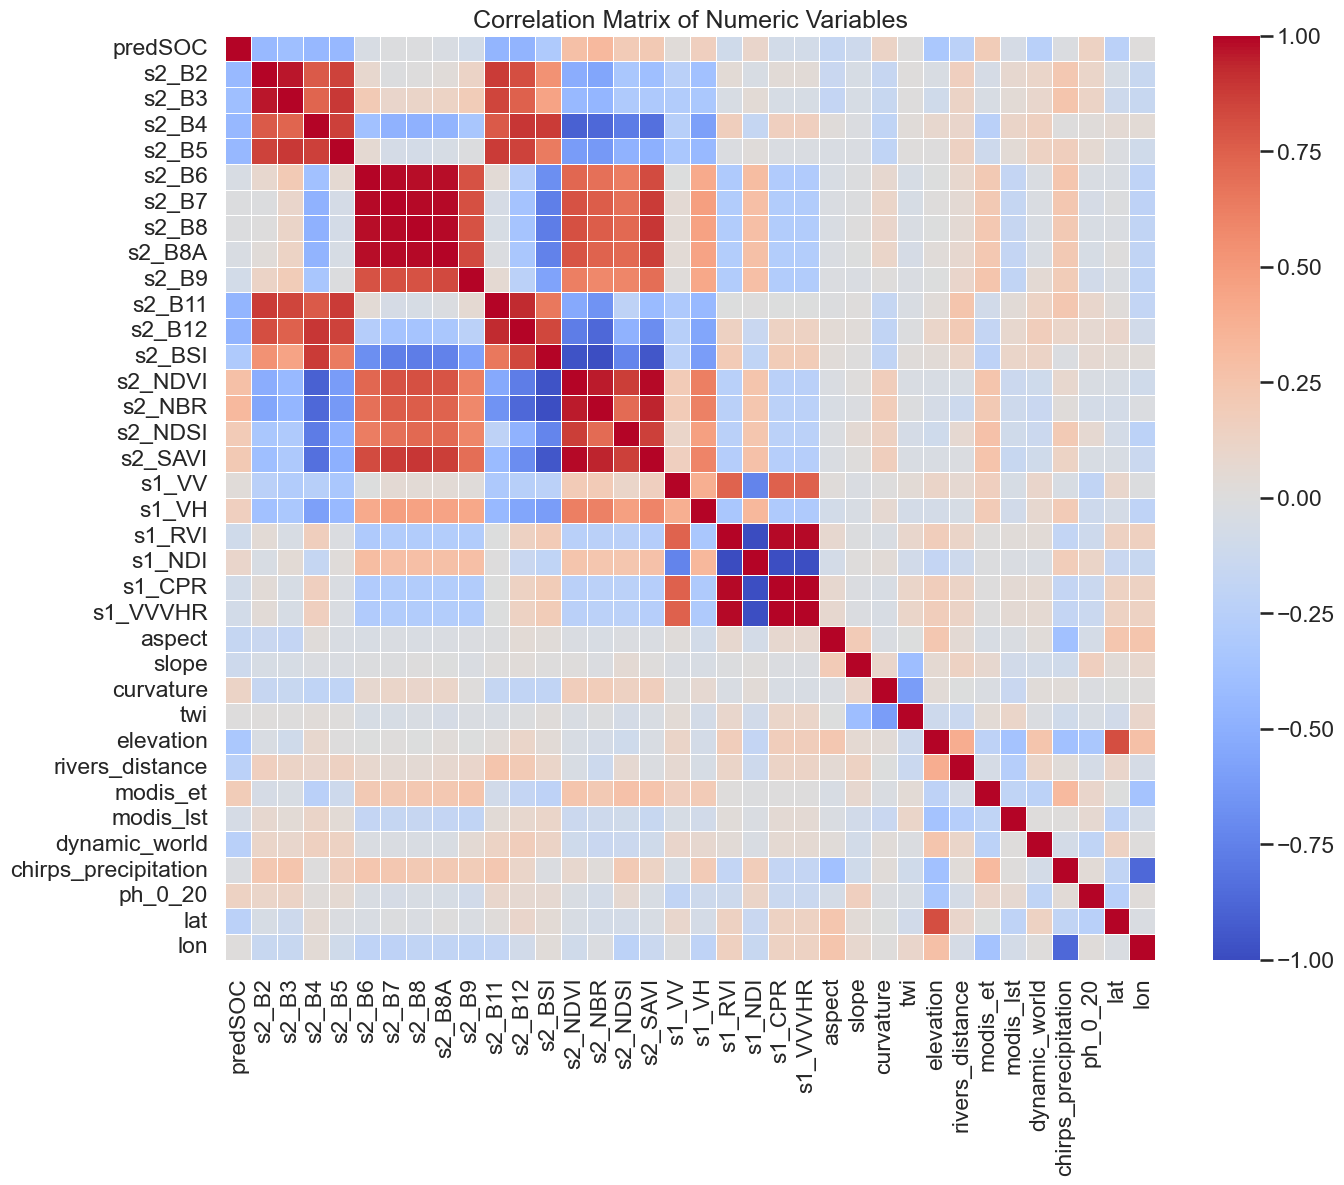

In [161]:
# 2. Select only numeric columns
numeric_data = sampled_data.select_dtypes(include=np.number)

# 3. Compute the correlation matrix
corr_matrix = numeric_data.corr()

# 4. Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables', fontsize=18)
plt.show()

In [162]:
import numpy as np
from scipy.spatial import distance_matrix

# Assume sampled_data is your GeoDataFrame
# Make sure it has:
# - geometry column
# - a variable of interest, e.g., 'total_count'

# 1. Extract the variable you want to test

y = sampled_data['predSOC'].values  # Replace with your column

# 2. Extract coordinates from the geometry
coords = np.array([(point.x, point.y) for point in sampled_data.geometry])

# 3. Compute pairwise distance matrix
dist_matrix = distance_matrix(coords, coords)

# 4. Inverse distance weights
np.fill_diagonal(dist_matrix, np.inf)  # Avoid division by zero
weights = 1 / dist_matrix

# 5. Row-standardize the weights
weights = weights / weights.sum(axis=1, keepdims=True)

# 6. Moran's I calculation
y_mean = np.mean(y)

# Numerator
num = 0
for i in range(len(y)):
    for j in range(len(y)):
        num += weights[i, j] * (y[i] - y_mean) * (y[j] - y_mean)

# Denominator
den = np.sum((y - y_mean)**2)

# Moran's I
moran_i = (len(y) / weights.sum()) * (num / den)

print(f"Moran's I: {moran_i:.4f}")


Moran's I: 0.1743


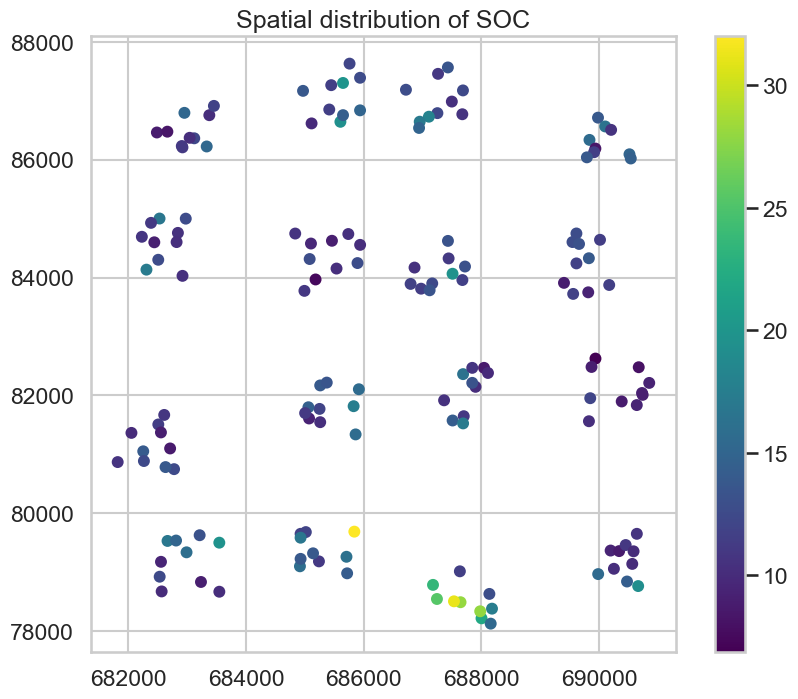

In [163]:
import matplotlib.pyplot as plt

# Plot sampled_data points colored by 'total_count'
fig, ax = plt.subplots(figsize=(10, 8))
sampled_data.plot(column='predSOC', cmap='viridis', legend=True, markersize=50, ax=ax)
plt.title('Spatial distribution of SOC')
plt.show()


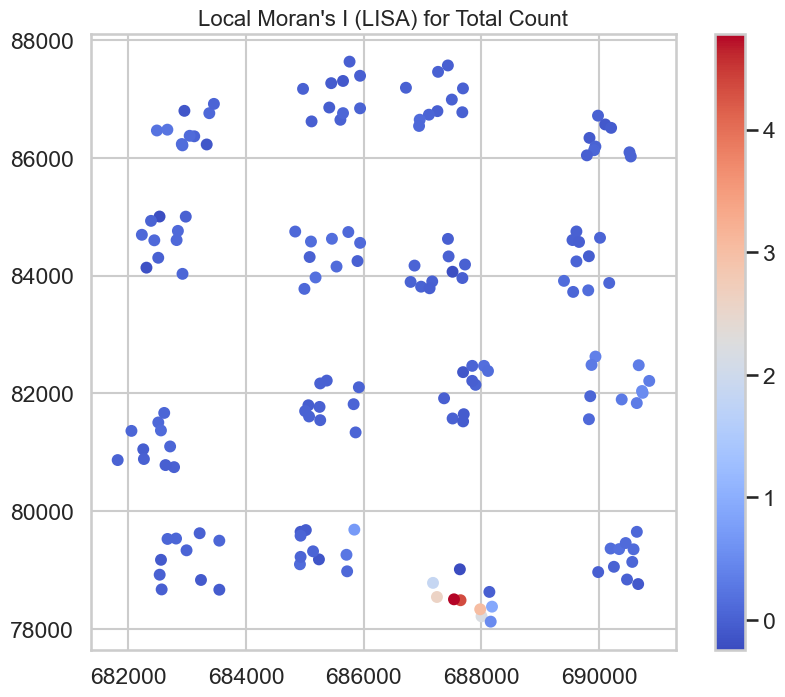

In [164]:
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import geopandas as gpd

# Assume sampled_data exists and has a geometry column and a value column like 'total_count'

# 1. Extract coordinates and variable
coords = np.array([(point.x, point.y) for point in sampled_data.geometry])
y = sampled_data['predSOC'].values

# 2. Create distance matrix
dist_matrix = distance_matrix(coords, coords)

# 3. Inverse distance weights
np.fill_diagonal(dist_matrix, np.inf)
weights = 1 / dist_matrix

# 4. Row-standardize weights
weights = weights / weights.sum(axis=1, keepdims=True)

# 5. Mean and standardize y
y_mean = np.mean(y)
y_std = np.std(y)
z = (y - y_mean) / y_std  # Standardized values

# 6. Calculate Local Moran's I for each point
local_moran_i = []

for i in range(len(y)):
    zi = z[i]
    neighbors = weights[i, :]
    local_I = zi * np.sum(neighbors * z)
    local_moran_i.append(local_I)

local_moran_i = np.array(local_moran_i)

# 7. Attach Local Moran's I to your sampled_data
sampled_data['local_moran_I'] = local_moran_i

# 8. Plot Local Moran's I
fig, ax = plt.subplots(figsize=(10, 8))
sampled_data.plot(column='local_moran_I', cmap='coolwarm', legend=True, markersize=50, ax=ax)
plt.title("Local Moran's I (LISA) for Total Count", fontsize=16)
plt.show()
